In [1]:
import torch, os, pickle
import pandas as pd
import matplotlib.pyplot as plt

from models import (
    get_device, load_artifacts, build_model,
    EfficientNetV2Encoder, extract_and_cache_features,
    build_cached_dataloaders, build_dataloaders,
    train_model, unfreeze_encoder_blocks,
    save_checkpoint, load_checkpoint,
)

CFG = dict(
    embed_dim        = 300,      # GloVe dimension
    units            = 512,      # hidden size & attention dim
    num_heads        = 8,        # 512/8 = 64 per head
    dropout          = 0.35,
    label_smoothing  = 0.1,
    # Phase 1: decoder-only on cached features
    p1_batch         = 2048,     # no image I/O → GPU can handle large batch
    p1_epochs        = 15,
    p1_lr            = 5e-4,
    p1_workers       = 8,
    # Phase 2: end-to-end fine-tune
    p2_batch         = 512,      # EfficientNetV2-S + decoder fits on 80 GB
    p2_epochs        = 10,
    p2_lr            = 5e-4,     # encoder blocks get 10x lower LR (5e-5)
    p2_finetune_blks = 2,
    p2_workers       = 8,
    use_amp          = True,     # bfloat16 — native on H100
    use_wandb        = False,
)
print("CFG loaded.")

CFG loaded.


In [2]:
device    = get_device()
artifacts = load_artifacts('artifacts/eda_artifacts.pkl')
VOCAB     = artifacts['vocab_size']
GLOVE     = artifacts['glove_matrix']

print(f"Vocab size  : {VOCAB:,}")
print(f"GloVe shape : {GLOVE.shape}")
print(f"Train pairs : {len(artifacts['train_df']):,}")
print(f"Val   pairs : {len(artifacts['val_df']):,}")
print(f"Test  pairs : {len(artifacts['test_df']):,}")

GPU : NVIDIA H100 80GB HBM3
VRAM: 85 GB


Vocab size  : 13,140
GloVe shape : (13140, 300)
Train pairs : 532,576
Val   pairs : 29,587
Test  pairs : 29,590


## Phase 1-A — Extract & cache EfficientNetV2-S features
Runs the encoder once over all images and saves `(N, 144, 512)` float16 to disk. Takes ~8 min on H100. Skipped automatically if cache already exists.

In [3]:
CACHE_DIR = 'artifacts/feature_cache'
os.makedirs('saved_models', exist_ok=True)

# Build frozen encoder just for feature extraction
enc = EfficientNetV2Encoder(
    feature_dim      = CFG['units'],
    fine_tune_blocks = 0,
).to(device)

# Combine all splits — cache every unique image once
all_df = pd.concat([
    artifacts['train_df'],
    artifacts['val_df'],
    artifacts['test_df'],
], ignore_index=True).drop_duplicates('image')

features_arr, path2idx = extract_and_cache_features(
    enc, all_df, CACHE_DIR, device, batch_size=512
)

print(f"Cache shape : {features_arr.shape}")   # (N_images, 144, 512)
print(f"Cache dtype : {features_arr.dtype}")   # float16
del enc
torch.cuda.empty_cache()

Extracting features for 118,287 images → artifacts/feature_cache


Extracting:   0%|          | 0/232 [00:00<?, ?it/s]

Saved: artifacts/feature_cache/features.npy  (17.4 GB)
Cache shape : (118287, 144, 512)
Cache dtype : float16


## Phase 1-B — Build cached DataLoaders

In [4]:
train_c, val_c, _ = build_cached_dataloaders(
    artifacts, features_arr, path2idx,
    batch_size  = CFG['p1_batch'],
    num_workers = CFG['p1_workers'],
)
print(f"Train batches : {len(train_c):,}  (batch={CFG['p1_batch']})")
print(f"Val   batches : {len(val_c):,}")

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
    free_gb = torch.cuda.mem_get_info()[0] / 1e9
    print(f"VRAM free before training : {free_gb:.1f} GB")

Train batches : 261  (batch=2048)
Val   batches : 15
VRAM free before training : 83.8 GB


## Phase 1-C — Train GRU-Attn and LSTM-Attn (frozen encoder)

In [5]:
p1_histories = {}

for mtype in ('gru_attn', 'lstm_attn'):
    print(f"\n{'='*55}  {mtype.upper()}  — Phase 1")

    model = build_model(
        mtype, VOCAB, GLOVE,
        embed_dim        = CFG['embed_dim'],
        units            = CFG['units'],
        num_heads        = CFG['num_heads'],
        dropout          = CFG['dropout'],
        fine_tune_blocks = 0,
    ).to(device)

    model = torch.compile(model)   # H100 speed boost

    trainable = sum(p.numel() for p in model.parameters()
                    if p.requires_grad)
    print(f"  Trainable : {trainable/1e6:.1f}M params  (decoder only)")

    h = train_model(
        model, train_c, val_c, device,
        epochs          = CFG['p1_epochs'],
        lr              = CFG['p1_lr'],
        use_amp         = CFG['use_amp'],
        label_smoothing = CFG['label_smoothing'],
        cached          = True,
        use_wandb       = CFG['use_wandb'],
        run_name        = f'{mtype}_p1',
    )
    save_checkpoint(model, h, CFG, f'saved_models/{mtype}_phase1.pth')
    p1_histories[mtype] = h
    print(f"  Best val  : {h['best_val_loss']:.4f} | "
          f"Time : {h['elapsed_s']/60:.1f} min")

# VRAM report
if torch.cuda.is_available():
    used  = torch.cuda.max_memory_allocated() / 1e9
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"\nPeak VRAM : {used:.1f} / {total:.0f} GB  "
          f"({used/total*100:.0f}%)")
    if used / total < 0.5:
        print("Tip: GPU is under 50% — consider raising p1_batch further.")


=======================================================  GRU_ATTN  — Phase 1
  Trainable : 14.6M params  (decoder only)


Train:   0%|          | 0/261 [00:00<?, ?it/s]

Val:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch  1/15 | train 4.6069 | val 3.7451 | lr 4.95e-04
   ✓ best val: 3.7451


Train:   0%|          | 0/261 [00:00<?, ?it/s]

...

Val:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 14/15 | train 3.2240 | val 3.2820 | lr 1.04e-05
   ✓ best val: 3.2820


Train:   0%|          | 0/261 [00:00<?, ?it/s]

Val:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 15/15 | train 3.2194 | val 3.2817 | lr 5.00e-06
   ✓ best val: 3.2817
Saved → saved_models/lstm_attn_phase1.pth
  Best val  : 3.2817 | Time : 30.7 min

Peak VRAM : 47.5 / 85 GB  (56%)


## Phase 2-A — Build live DataLoaders (raw images, augmented)

In [6]:
train_live, val_live, _ = build_dataloaders(
    artifacts,
    batch_size  = CFG['p2_batch'],
    num_workers = CFG['p2_workers'],
)
print(f"Train batches : {len(train_live):,}  (batch={CFG['p2_batch']})")
print(f"Val   batches : {len(val_live):,}")

Train batches : 1,041  (batch=512)
Val   batches : 58


## Phase 2-B — Fine-tune last 2 EfficientNetV2-S blocks end-to-end
Encoder unfrozen blocks get LR = 5e-5 (10× lower than decoder).

In [7]:
p2_histories = {}

for mtype in ('gru_attn', 'lstm_attn'):
    print(f"\n{'='*55}  {mtype.upper()}  — Phase 2")

    # Load Phase-1 checkpoint (frozen encoder)
    model, _ = load_checkpoint(
        mtype,
        f'saved_models/{mtype}_phase1.pth',
        device, VOCAB,
        embed_dim        = CFG['embed_dim'],
        units            = CFG['units'],
        num_heads        = CFG['num_heads'],
        dropout          = CFG['dropout'],
        fine_tune_blocks = 0,
    )

    # Unfreeze last 2 EfficientNetV2-S blocks
    unfreeze_encoder_blocks(model, n_blocks=CFG['p2_finetune_blks'])

    model = torch.compile(model)

    h = train_model(
        model, train_live, val_live, device,
        epochs          = CFG['p2_epochs'],
        lr              = CFG['p2_lr'],
        use_amp         = CFG['use_amp'],
        label_smoothing = CFG['label_smoothing'],
        cached          = False,
        use_wandb       = CFG['use_wandb'],
        run_name        = f'{mtype}_p2',
    )
    save_checkpoint(model, h, CFG, f'saved_models/{mtype}_final.pth')
    p2_histories[mtype] = h
    print(f"  Best val  : {h['best_val_loss']:.4f} | "
          f"Time : {h['elapsed_s']/60:.1f} min")

# VRAM report
if torch.cuda.is_available():
    used  = torch.cuda.max_memory_allocated() / 1e9
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"\nPeak VRAM : {used:.1f} / {total:.0f} GB  "
          f"({used/total*100:.0f}%)")


=======================================================  GRU_ATTN  — Phase 2
Phase-2: unfroze last 2 encoder blocks → 29.5M trainable params


Train:   0%|          | 0/1041 [00:00<?, ?it/s]

Val:   0%|          | 0/58 [00:00<?, ?it/s]

Epoch  1/10 | train 3.4389 | val 3.2865 | lr 4.88e-04
   ✓ best val: 3.2865


Train:   0%|          | 0/1041 [00:00<?, ?it/s]

...

Val:   0%|          | 0/58 [00:00<?, ?it/s]

Epoch  9/10 | train 3.0968 | val 3.1510 | lr 1.71e-05
   ✓ best val: 3.1510


Train:   0%|          | 0/1041 [00:00<?, ?it/s]

Val:   0%|          | 0/58 [00:00<?, ?it/s]

Epoch 10/10 | train 3.0853 | val 3.1495 | lr 5.00e-06
   ✓ best val: 3.1495
Saved → saved_models/lstm_attn_final.pth
  Best val  : 3.1495 | Time : 196.3 min

Peak VRAM : 47.5 / 85 GB  (56%)


## Loss curves — both phases, both models

In [12]:
import matplotlib
matplotlib.use("Agg")

Saved to: training_curves.png


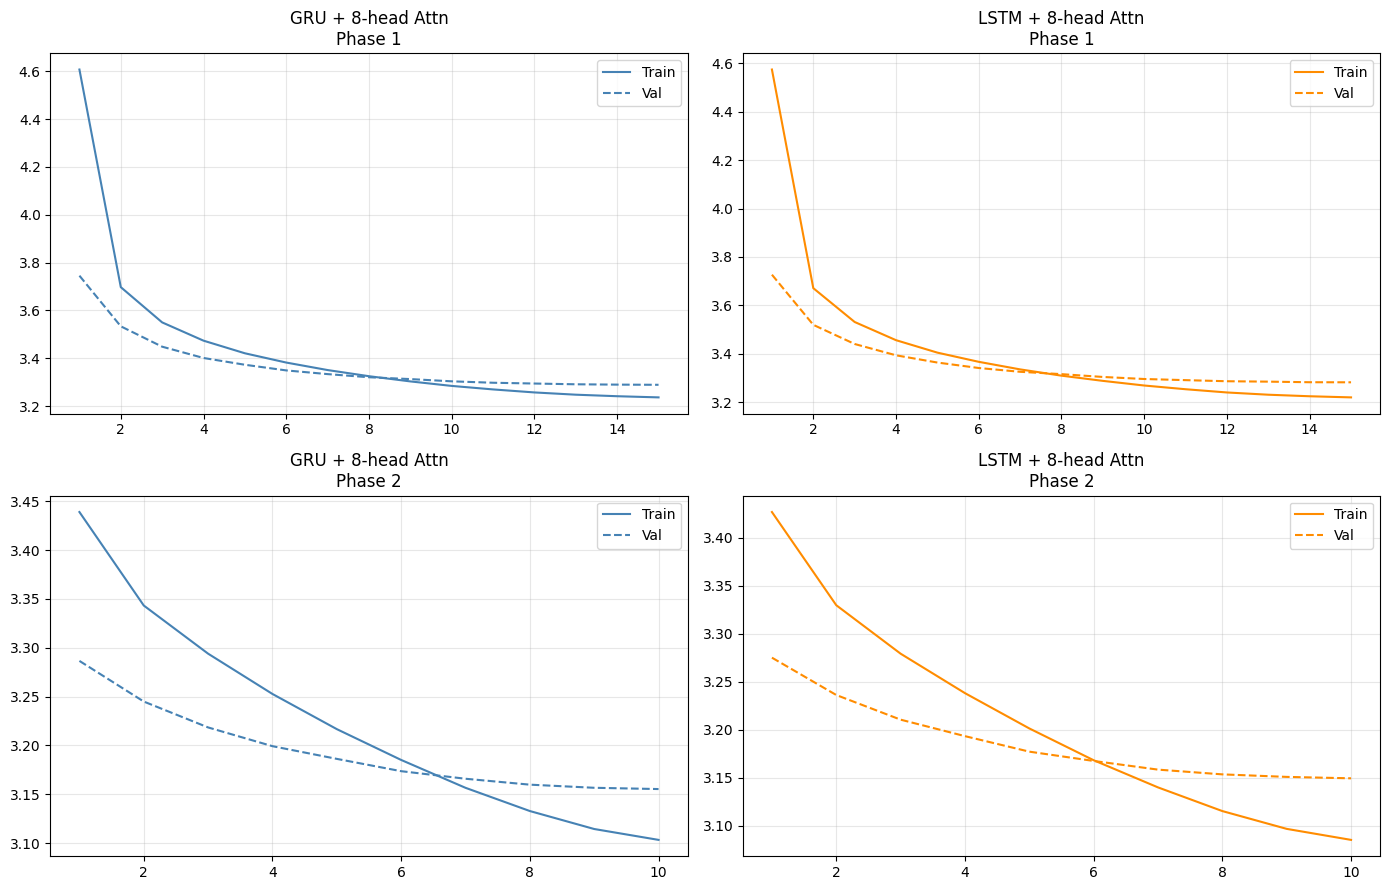

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

colors = {'gru_attn': 'steelblue', 'lstm_attn': 'darkorange'}

for col, mtype in enumerate(('gru_attn', 'lstm_attn')):
    label = 'GRU + 8-head Attn' if mtype == 'gru_attn' else 'LSTM + 8-head Attn'
    c = colors[mtype]

    for row, (h, phase) in enumerate([
        (p1_histories[mtype], 'Phase 1'),
        (p2_histories[mtype], 'Phase 2')
    ]):

        ax = axes[row][col]
        ep = range(1, len(h['train_loss']) + 1)

        ax.plot(ep, h['train_loss'], label='Train', color=c)
        ax.plot(ep, h['val_loss'], '--', label='Val', color=c)

        ax.set_title(f"{label}\n{phase}")
        ax.legend()
        ax.grid(alpha=0.3)

plt.tight_layout()

# save image
path = "training_curves.png"
plt.savefig(path, dpi=300)

print(f"Saved to: {path}")

In [23]:
import os
os.path.getsize("training_curves.png")

390125

## Save training results

In [9]:
with open('artifacts/training_results.pkl', 'wb') as f:
    pickle.dump({'p1': p1_histories, 'p2': p2_histories, 'cfg': CFG}, f)
print("Saved artifacts/training_results.pkl")

print("\nModel           | Phase 1 best val | Phase 2 best val")
print("-" * 56)
for mtype in ('gru_attn', 'lstm_attn'):
    p1v = p1_histories[mtype]['best_val_loss']
    p2v = p2_histories[mtype]['best_val_loss']
    print(f" {mtype:<18}| {p1v:.4f}           | {p2v:.4f}")

Saved artifacts/training_results.pkl

Model           | Phase 1 best val | Phase 2 best val
--------------------------------------------------------
 gru_attn          | 3.2890           | 3.1554
 lstm_attn         | 3.2817           | 3.1495
